In [81]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e7')

print("Path to competition files:", path)

Path to competition files: /Users/jaquesgillis/.cache/kagglehub/competitions/playground-series-s6e7


In [96]:
from setup import *
import os

os.listdir(path)

['test.csv', 'train.csv', 'sample_submission.csv']

In [184]:
df = pd.read_csv(path + '/train.csv')

In [185]:
X = df.copy()
X.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## Expectations

Most of the independent variables here should have a strong relationship with the target (health_condition). One would expect sleep_duration to have a nearly linear relationship with health_condition up to about 8 or 9 hours, and (if there are longer sleep durations in the data set) to fall again. Similar relationships seem likely with heart_rate, and bmi. We might find a more linear relationship between the target and calorie_expenditure, step_count, exercise_duration, water_intake, stress_level, and sleep_quality. 

It also seems likely that many of these features have significant covariance in certain intervals. Some of them may vary with undocumented health conditions. 

## Procedure

The table needs cleaning, and the categorical variables need to be encoded. So first, we'll take care of NaN's and then we'll ordinal encode stress_level, sleep_quality, and the target and one-hot encode diet_type, smoking_alcohol, and gender. Finally, we'll separate the target and train a baseline model before beginning deeper exploration of the features.

In [186]:
# Find columns with null values

print(f"length of table: {len(X)}")

features = X.columns

for feature in features:
    if X[feature].isnull().values.any():
        print(f"{X[feature].isnull().sum()/len(X)} proportion null rows for {feature}")

length of table: 690088
0.1101294327679948 proportion null rows for sleep_duration
0.011350726284184046 proportion null rows for heart_rate
0.020139460474606137 proportion null rows for bmi
0.07658878287986459 proportion null rows for calorie_expenditure
0.020165544104520004 proportion null rows for step_count
0.010000173890866092 proportion null rows for exercise_duration
0.06300210987584193 proportion null rows for water_intake
0.010000173890866092 proportion null rows for diet_type
0.12000063759984234 proportion null rows for stress_level
0.0845269009169845 proportion null rows for sleep_quality
0.05306714505976049 proportion null rows for physical_activity_level
0.04141790612211776 proportion null rows for smoking_alcohol
0.030971412341614404 proportion null rows for gender


As this is synthetic data, the patterns in where the null values fall may not reflect real phenomena. Nevertheless, we might guess that values for sleep_duration, heart_rate, and other clinical features would be most likely to be recorded when they are pathological. These can probably be imputed by a simple sample mean, or by a larger population mean (e.g., 7 hours sleep per night, based on the US population). smoking_alcohol seems most likely to be underreported, with nulls being unreported positives. null genders could represent a third category, "other."

In [187]:
#########################################################################
# For the inputations below, I'm favoring the "outside" view by taking
# US population statistics when they are available and seem likely to fit
# in a college population.
#########################################################################

# Use the US population mean to replace missing sleep duration values
X['sleep_duration'] = X['sleep_duration'].mask(X['sleep_duration'].isnull(), other=7.0)
# Because of high variability of heart rate statistics, use the 
# sample mean for heart_rate
X['heart_rate'] = X['heart_rate'].mask(X['heart_rate'].isnull(), other=X['sleep_duration'].mean())
# https://dqydj.com gives a median bmi of 25.5 for 18-24 year olds
X['bmi'] = X['bmi'].mask(X['bmi'].isnull(), other=25.5)
# The following seem like local statistics, so I'll take the mean of the sample'
# Using median for quantitative variables and mode for categorical
X['calorie_expenditure'] = X['calorie_expenditure'].mask(X['calorie_expenditure'].isnull(), other=X['calorie_expenditure'].median())
X['step_count'] = X['step_count'].mask(X['step_count'].isnull(), other=X['step_count'].median())
X['exercise_duration'] = X['exercise_duration'].mask(X['exercise_duration'].isnull(), other=X['exercise_duration'].median())
X['water_intake'] = X['water_intake'].mask(X['water_intake'].isnull(), other=X['water_intake'].median())
X['diet_type'] = X['diet_type'].mask(X['diet_type'].isnull(), other=X['diet_type'].mode()[0])
X['stress_level'] = X['stress_level'].mask(X['stress_level'].isnull(), other=X['stress_level'].mode()[0])
X['sleep_quality'] = X['sleep_quality'].mask(X['sleep_quality'].isnull(), other=X['sleep_quality'].mode()[0])
X['physical_activity_level'] = X['physical_activity_level'].mask(X['physical_activity_level'].isnull(), X['physical_activity_level'].mode()[0])
# I'll take a pessimistic view and assume that unreported smoking/drinking means 'yes'
X['smoking_alcohol'] = X['smoking_alcohol'].mask(X['smoking_alcohol'].isnull(), other='yes')
# Create a third category, "other", for null gender values
X['gender'] = X['gender'].mask(X['gender'].isnull(), other="other")

X_with_categories = X.copy()

In [188]:
X = X.drop(columns=['id'])

##################
# One-hot encoding
##################

categorical = ['diet_type', 'smoking_alcohol', 'gender']

one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

for category in categorical:
    # encode
    new_column_data = one_hot.fit_transform(X[[category]])
    # get names for the one-hot-encoded columns
    new_column_names = one_hot.get_feature_names_out([category])
    # wrap in dataframe
    new_columns = pd.DataFrame(new_column_data, columns=new_column_names)
    # attach to the main dataframe
    X = pd.concat([X.drop(columns=category, axis=1), new_columns], axis=1)


In [189]:
################
# Ordinal encode
################

ordinal = ['health_condition', 'sleep_quality', 'stress_level', 'physical_activity_level']

ordinal_values = {}
ordinal_values['health_condition'] = ['unhealthy', 'at-risk', 'fit']
ordinal_values['sleep_quality'] = ['poor', 'average', 'good']
ordinal_values['stress_level'] = ['low', 'medium', 'high']
ordinal_values['physical_activity_level'] = ['sedentary', 'moderate', 'active']

for category in ordinal:
    encoder = OrdinalEncoder(categories=[ordinal_values[category]])
    X[category + '_encoded'] = encoder.fit_transform(X[[category]])
    X.drop(columns=[category], inplace=True)

## Baseline model

In [190]:
y = X.pop('health_condition_encoded')

In [191]:
#Train a baseline model

rf_model = RandomForestClassifier(n_estimators=100, max_depth=9)
train_X, val_X, train_y, val_y = train_test_split(X, y)
rf_model.fit(train_X, train_y)
val_predictions = rf_model.predict(val_X)
print(f"Baseline balanced accuracy score: {balanced_accuracy_score(val_y, val_predictions)}")

Baseline balanced accuracy score: 0.8372588999906502


In [192]:
X_with_categories.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,medium,average,sedentary,yes,male


Text(0.5, 0, '[57724, 592561, 39803]')

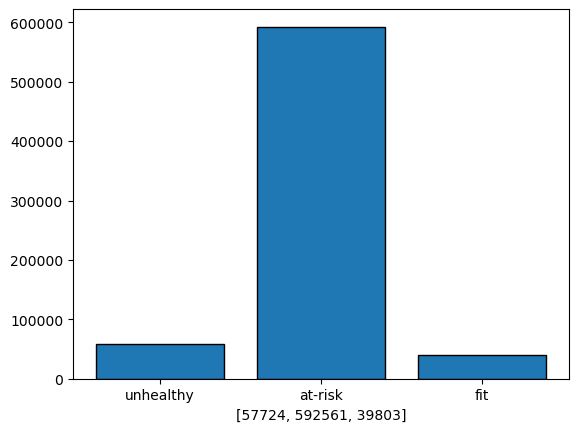

In [193]:
# Check the sizes of the target categories
cats = X_with_categories['health_condition'].unique().tolist()
vals = [len(X_with_categories[X_with_categories['health_condition'] == cat]) for cat in cats]
plt.bar(cats, vals, edgecolor='black')
plt.xlabel(vals)

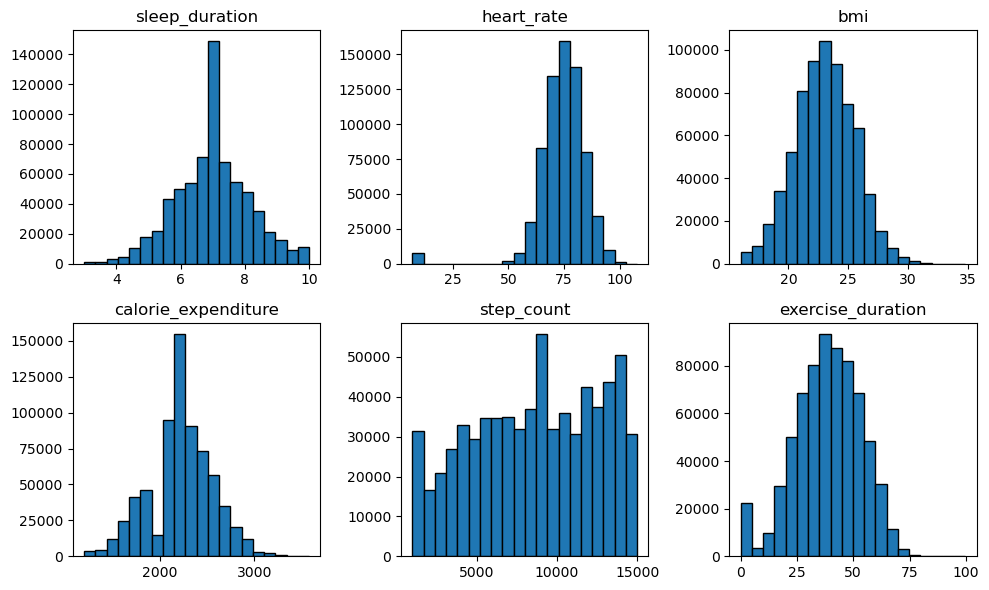

In [194]:
num_features = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for feature in num_features:
    ax = next(axes_iterator)
    ax.hist(X[feature], bins=20, edgecolor='black')
    ax.set_title(feature)
plt.tight_layout()
plt.show()

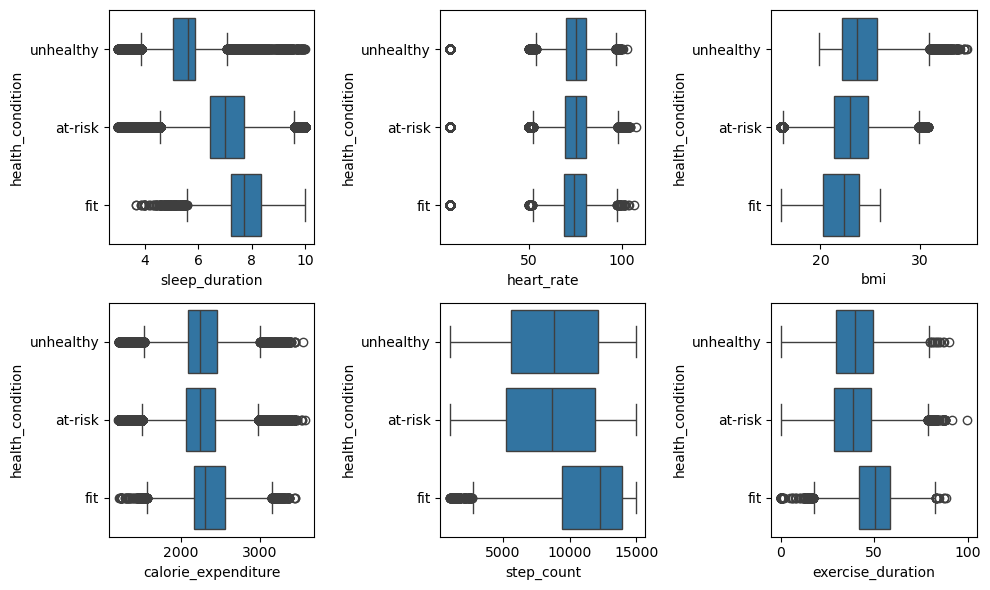

In [195]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))

for i, feature in enumerate(num_features):
    row = int(i / 3)
    col = int(i % 3)
    sns.boxplot(x=X_with_categories[feature], y=X_with_categories['health_condition'], ax=axes[row, col])
    ax.set_title(feature)
plt.tight_layout()
plt.show()


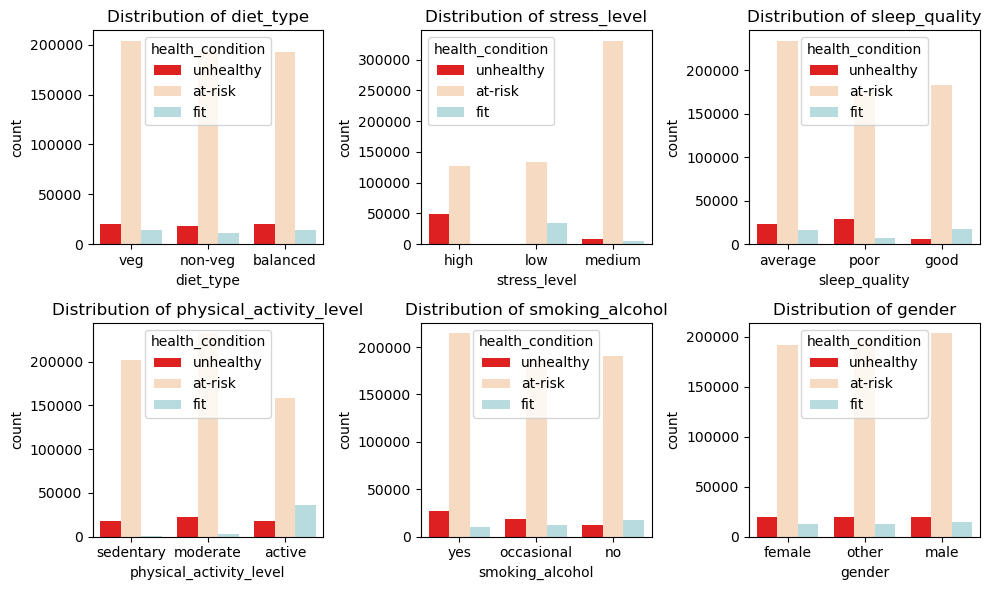

In [197]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes = axes.flatten()

cat_features = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
bar_colors = ['red', 'peachpuff', 'powderblue']

for i, feature in enumerate(cat_features):
    sns.countplot(
        x=X_with_categories[feature], 
        hue=X_with_categories['health_condition'], 
        ax=axes[i],
        palette=bar_colors
    )
    axes[i].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## Comment

The size of the at-risk group makes it hard to see the patterns that depend on the smaller groups. Let's try taking the group out and looking again.

In [198]:
# Make a new dataframe without the 'at-risk' group

X_no_risk = X_with_categories[(X_with_categories['health_condition'] == 'unhealthy') | (X_with_categories['health_condition'] == 'fit')]
X_no_risk.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
8,8,unhealthy,5.94,75.4,24.36,2241.0,12165.0,61.6,1.56,veg,high,average,active,no,other
17,17,fit,7.71,77.4,21.55,2439.0,14054.0,61.4,1.34,non-veg,low,good,active,occasional,male


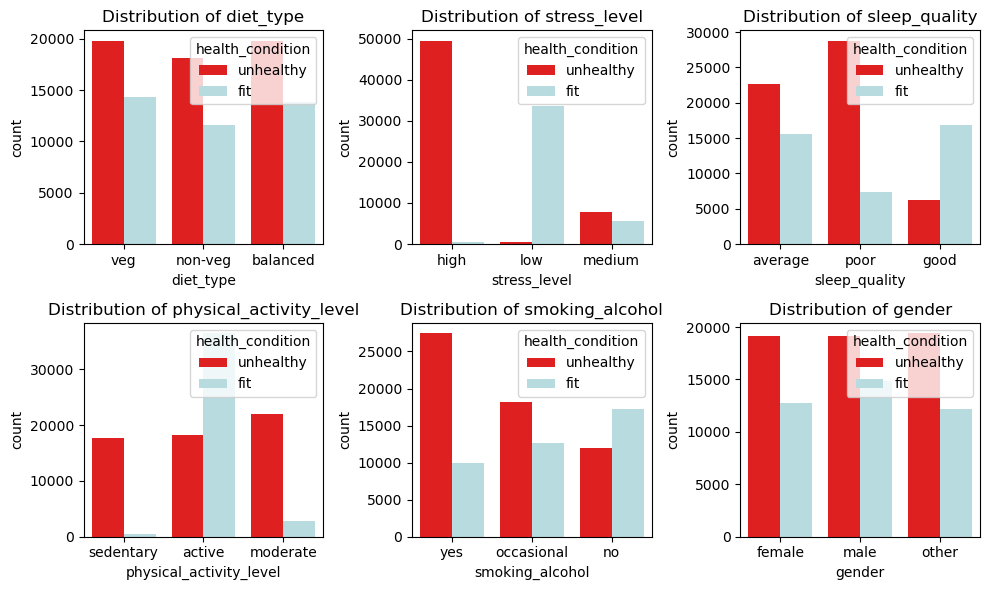

In [199]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes = axes.flatten()

cat_features = ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
bar_colors2 = ['red', 'powderblue']

for i, feature in enumerate(cat_features):
    sns.countplot(
        x=X_no_risk[feature], 
        hue=X_no_risk['health_condition'], 
        ax=axes[i],
        palette=bar_colors2
    )
    axes[i].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## Discussion

The data are strongly unbalanced, with the number of students in the at-risk category an order of magnitude larger than the number of students in the other two categories. Nevertheless, the data set is large enough that we should have enough data for the smaller groups. During training, stratified folds will probably be necessary. 

Most of the relationships between independent variables and the target are not surprising. The two exceptions for me are diet type and heart rate, which appear to have little importance.


| Positive relationship with 'fit' | Negative relationship with 'fit' | Nonlinear relationship | No significant relationship |
| :--- | :--- | :--- | :--- |
| Sleep quality | Stress level | Steps | Diet type |
| Physical activity | Smoking/drinking | Exercise duration | Heart rate |
| Sleep duration | BMI | Calorie expenditure (weak) | 


Perhaps relative unimportance of diet type and heart rate can be explained by the youth of the subjects. Diet type would only gain importance over decades (if ever), and heart rate would only really be indicative of underlying health in older people. 

Another surprise is that unhealthy students and at-risk students resemble each other more than either resemble fit people. In other words, fit students are exceptional. This emerges from the nonlinear relationships above, where the unhealthy and at-risk groups have virtually identical distributions and the fit group has different distributions. 

Finally, the power of stress levels is striking. In these data, there are some fit students who are smokers and there are even some fit students (though few) who are sedentary, but there are almost no fit students with high stress levels, but there are quite a few unhealthy students with high stress levels. However, the direction of this relationship isn't clear: it could be that stress is so harmful that you can't be fit with high stress levels, or it could be that fitness prevents high stress levels. I would guess that the latter direction plays a larger role in these data.

## Hypotheses and tests

### Behavioral data

It seems likely that physical activity and smoking/drinking are causal and independent, while sleep quality, sleep duration, and stress level are partially dependent. In that case, we might try to isolate independent effects of sleep quality, sleep duration, and stress level from physical activity and smoking/drinking by subtracting physical activity and smoking/drinking from the other variables. 

### Physiological data

We only have two physiological features--heart rate and BMI. Heart rate does not appear significant in the large view, but it is likely to be become significant in some pathologies. It seems likely to interact with BMI in some of these cases. It is also possible that gender will interact with these.

## Interactions

Before testing the effects of feature engineering, let's see if partial dependence plots give us more information about possible interactions.

In [200]:
X.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_non-veg,diet_type_veg,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other,sleep_quality_encoded,stress_level_encoded,physical_activity_level_encoded
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,0.0
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


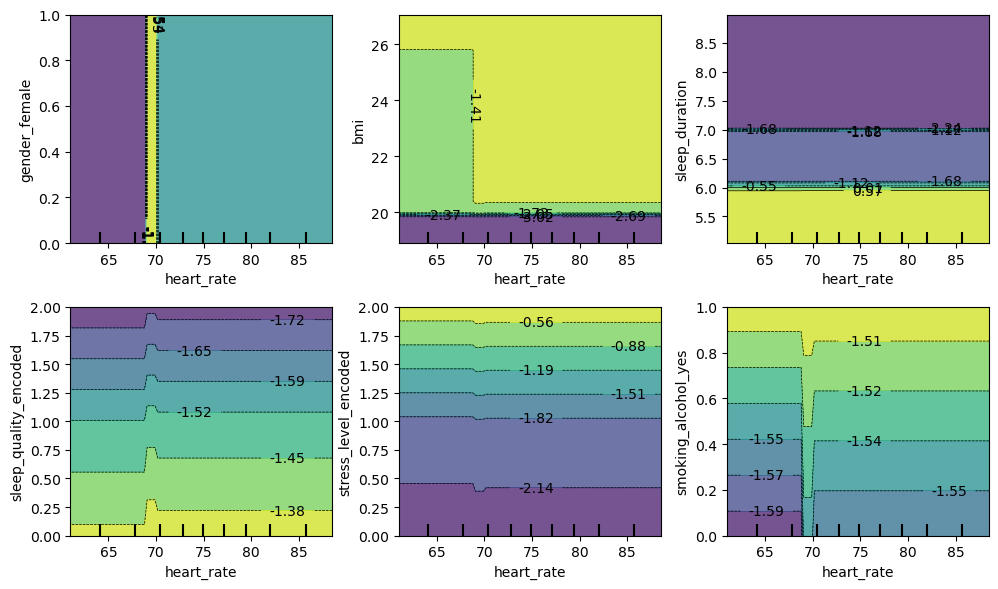

In [202]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import GradientBoostingClassifier

########### Test for interactions with partial dependence plots ############

# First let's look for interactions with heart rate
# The target here is 'unhealthy'
heart_out = ['gender_female', 'bmi', 'sleep_duration', 'sleep_quality_encoded', 'stress_level_encoded', 'smoking_alcohol_yes']

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0).fit(X, y)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for cat in heart_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('heart_rate', cat)], 
        target=0., 
        ax=ax)
plt.tight_layout()
plt.show() 

The graphs yield a few interesting relationships:
- High heart rate combined with high BMI is bad. BMI is less harmful with heart rates below 70 bpm. But heart rate doesn't matter for BMI's below 20.
- Smoking also has different effects when the heart rate is below 70 bpm than when it is above. It is more harmful when the heart rate is above 70 bpm.
- The benefits of sleep quality are more pronounced below 70 bpm.
- There appears to be no interaction between heart rate and gender, sleep duration, and stress level. There may be some very small interaction between heart rate and sleep quality, with 70 bpm again marking a nonlinearity.

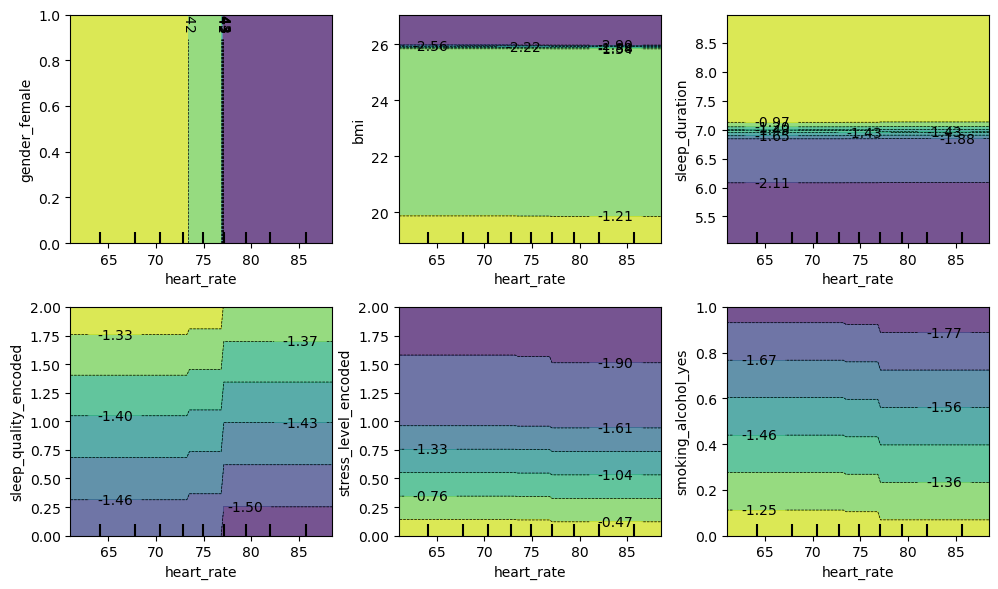

In [203]:
# Look at the same features, but with y='fit'

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for cat in heart_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('heart_rate', cat)], 
        target=2., 
        ax=ax)
plt.tight_layout()
plt.show() 

Sleep quality and smoking/alcohol still interact:
- Sleep quality improves fitness more when the heart rate is below about 78. 
- Smoking/alcohol hurt fitness more when the heart rate is above about 78.

These are similar to the patterns seen in the unhealthy population, but with the nonlinearity happening at a higher bpm. Perhaps higher heart rates exacerbate issues related to sleep and smoking, but fitness blunts the effect.

BMI no longer interacts with heart rate in this population. Perhaps that is due to a sparsity of data for the combination of fit and BMI > ~25.


In [182]:
X_with_categories['smoking_alcohol'].unique().tolist()

['yes', 'occasional', 'no']

In [205]:
X.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_non-veg,diet_type_veg,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_other,sleep_quality_encoded,stress_level_encoded,physical_activity_level_encoded
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,0.0
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


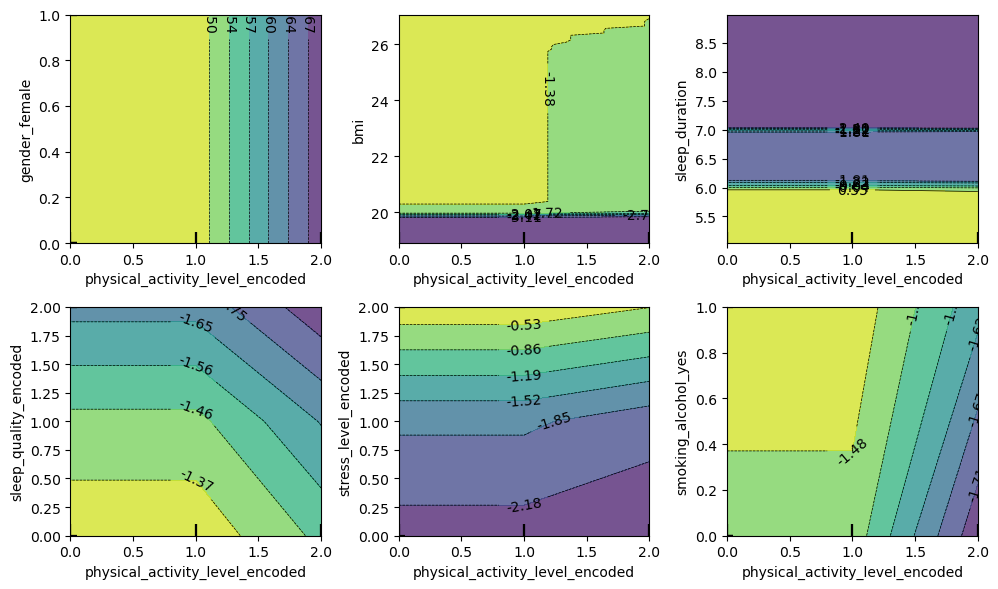

In [206]:
# Look at interactions with physical activity
# starting with the same features

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for cat in heart_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('physical_activity_level_encoded', cat)], 
        target=0., 
        ax=ax)
plt.tight_layout()
plt.show() 


- BMI and physical activity interact for high BMI, with high physical activity offering some protection up to BMI of about 26, but trailing off as BMI rises. 
- Sleep quality also has a nonlinear relationship to physical activity: for low physical activity, sleep quality dominates, but for moderate-to-high activity, sleep quality and physical activity have an additive relationship. 
- Smoking shows a similar pattern: for low physical activity, smoking dominates, but for higher physical activity levels, the relationship becomes additive (although smoking seems to have a larger coefficient). 

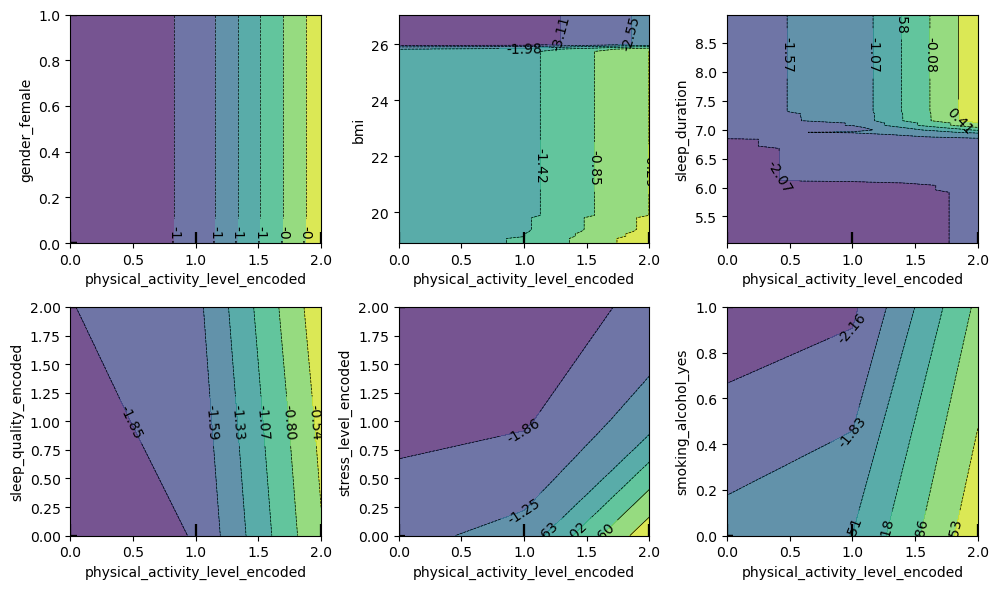

In [207]:
# Look at interactions with physical activity
# starting with the same features

physical_out = ['sleep_quality', 'stress_level', 'sleep_duration', 'heart_rate', 'bmi', 'diet_type_veg']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for cat in heart_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('physical_activity_level_encoded', cat)], 
        target=2., 
        ax=ax)
plt.tight_layout()
plt.show() 


- The significance of 26 in BMIs is very clear when we look at the 'fit' population. Very low BMIs seem to have a multiplicative effect with physical activity.
- There seems to be a multiplicative effect between sleep duration and physical activity, with low fitness pooling in the lower left corner and high fitness pooling in the upper right.
- Sleep quality, stress level, and smoking have more pronounced effects at lower activity levels. The effects of physical activity become stronger as it increases.

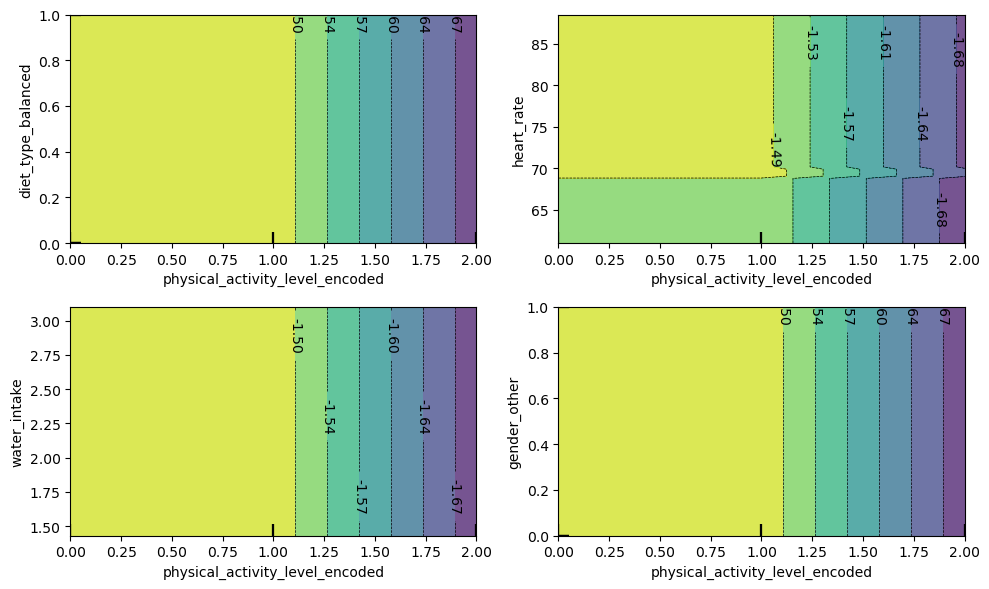

In [215]:

# Look at interactions with physical activity
# starting with likely covariances

physical_out = ['diet_type_balanced', 'heart_rate', 'water_intake', 'gender_other']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes_iterator = axes.flat

for cat in physical_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('physical_activity_level_encoded', cat)], 
        target=0., 
        ax=ax)
plt.tight_layout()
plt.show() 

High heart rate is more predictive of 'unhealthy' for low activity, but may still matter a little at higher activity levels.

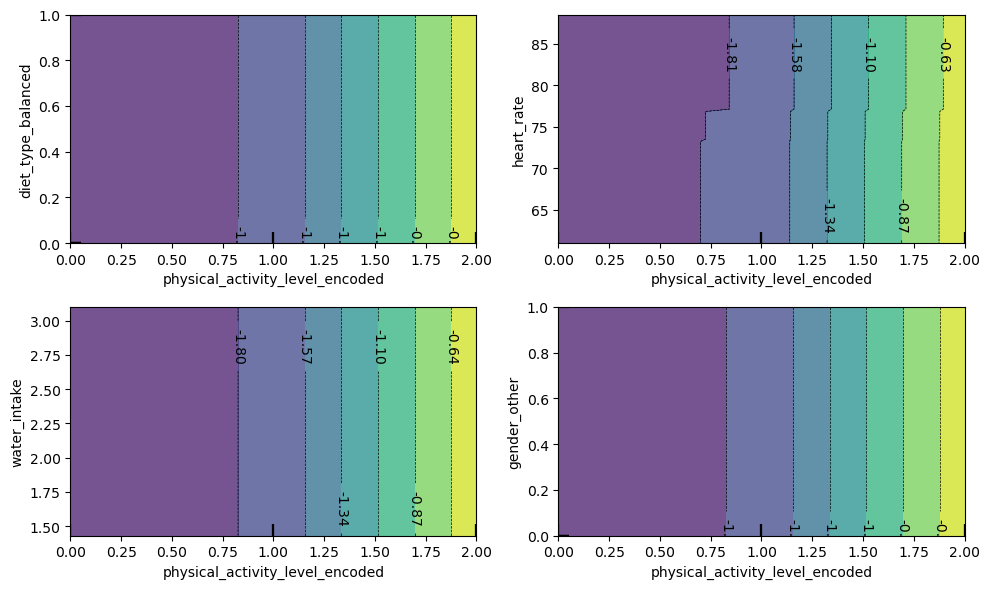

In [216]:

# Look at interactions with physical activity
# starting with likely covariances

physical_out = ['diet_type_balanced', 'heart_rate', 'water_intake', 'gender_other']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axes_iterator = axes.flat

for cat in physical_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('physical_activity_level_encoded', cat)], 
        target=2., 
        ax=ax)
plt.tight_layout()
plt.show() 

High activity seems to be much more predictive than heart rate of fitness, but the two interact a little.

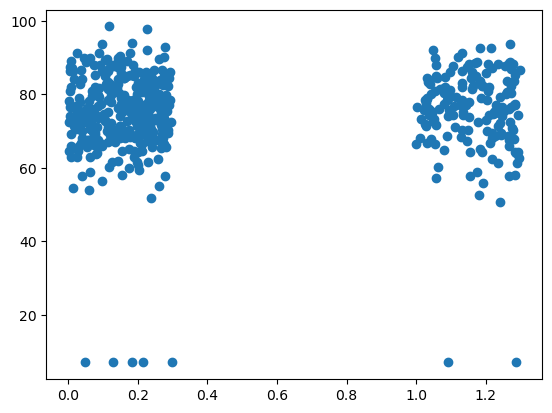

In [287]:
# Let's just look at whether smoking contributes directly to heart rate

datalen = len(X)
rand_index = np.random.rand(1,500) * datalen
rand_index = rand_index.astype(int).tolist()
rand_scatter = np.random.rand(1, 500)

scattered_smoke = X.iloc[rand_index[0]]['smoking_alcohol_yes'] + 0.3*rand_scatter[0]
plt.scatter(scattered_smoke, X['heart_rate'].iloc[rand_index[0]])


No contribution

These partial dependence plots have left out the largest population, 'at-risk'. If we can accurately predict the other two target labels, in theory we should be able to predict 'at-risk' just as accurately, but it's worth checking whether the relationships between features changes in this population.

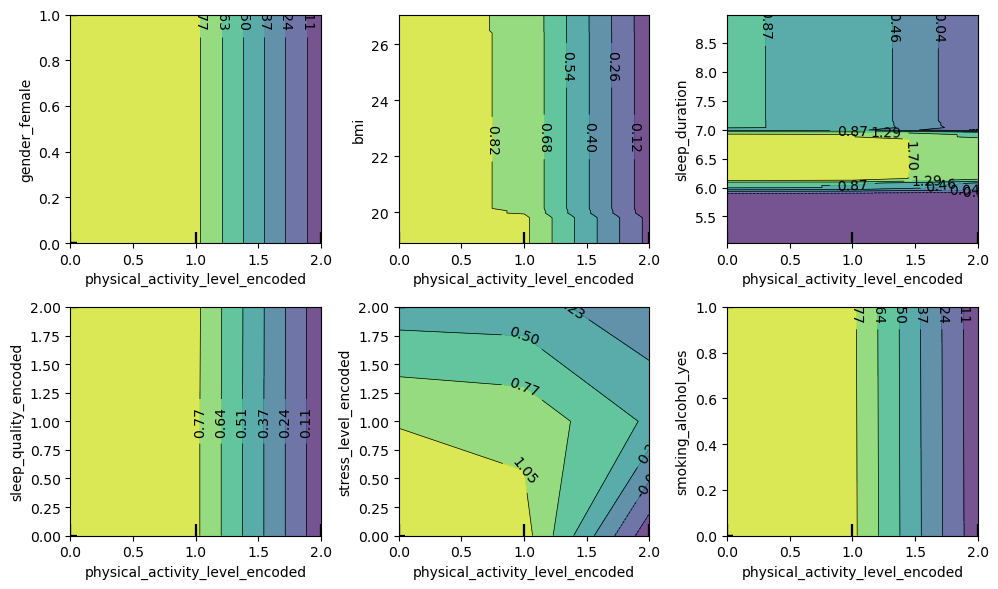

In [288]:
# Look at interactions with physical activity
# starting with the same features

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for cat in heart_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('physical_activity_level_encoded', cat)], 
        target=1., 
        ax=ax)
plt.tight_layout()
plt.show() 

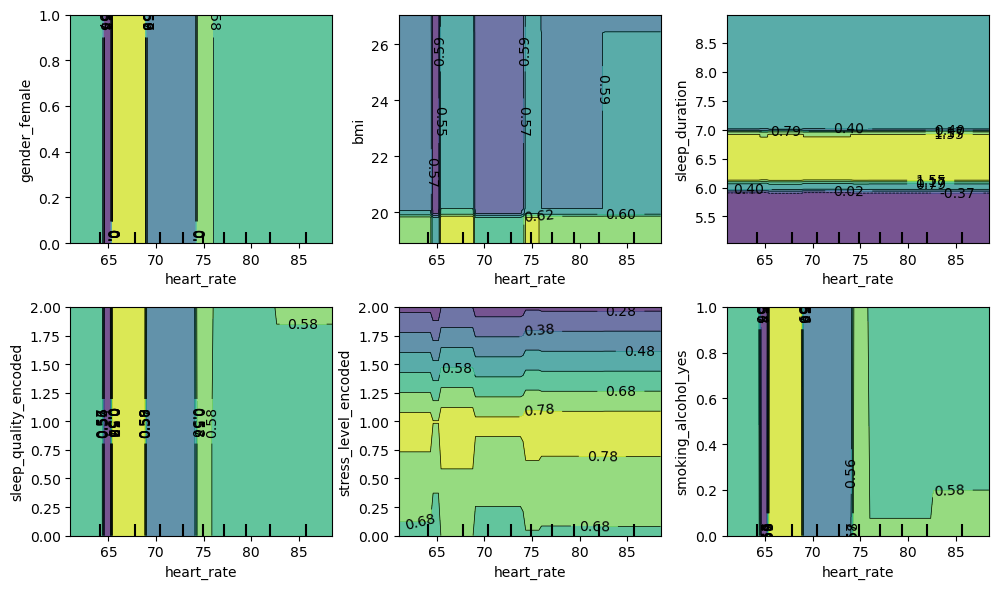

In [289]:
# Look at the same features, but with y='fit'

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6))
axes_iterator = axes.flat

for cat in heart_out:
    ax = next(axes_iterator)
    display = PartialDependenceDisplay.from_estimator(
        estimator=gbc, 
        X=X, 
        features=[('heart_rate', cat)], 
        target=1., 
        ax=ax)
plt.tight_layout()
plt.show() 